# NIFTY-Sentinel: latent regimes and connectedness
Fit unsupervised models only on the relevant training period when evaluating future test periods.

In [1]:
import os
os.chdir(r'C:\Users\deepa\Documents\ChatGPT\ML 2 porject')
import matplotlib.pyplot as plt
import pandas as pd
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from src.config import FIGURES_DIR, PROCESSED_DATA_DIR
from src.features import log_returns, rolling_connectedness

prices = pd.read_csv(PROCESSED_DATA_DIR / 'master_market_data.csv', parse_dates=['date']).set_index('date')
state = pd.read_csv(PROCESSED_DATA_DIR / 'market_state_features.csv', parse_dates=['date']).set_index('date')

In [2]:
regime_columns = ['nifty_log_return', 'volatility_20d', 'drawdown_60d', 'india_vix_change', 'usd_inr_return']
regime_input = state[regime_columns].dropna()
scaler = StandardScaler()
X = scaler.fit_transform(regime_input)
hmm = GaussianHMM(n_components=3, covariance_type='full', n_iter=300, random_state=42)
hmm.fit(X)
state.loc[regime_input.index, 'regime'] = hmm.predict(X)
state['regime'] = state['regime'].astype('Int64')
state.to_csv(PROCESSED_DATA_DIR / 'regime_features.csv')
state.groupby('regime')[regime_columns].mean().round(3)

,nifty_log_return,volatility_20d,drawdown_60d,india_vix_change,usd_inr_return
regime,,,,,
0,-0.000,0.163,-0.052,-0.001,0.000
1,-0.000,0.268,-0.113,0.012,0.001
2,0.001,0.109,-0.010,0.000,0.000


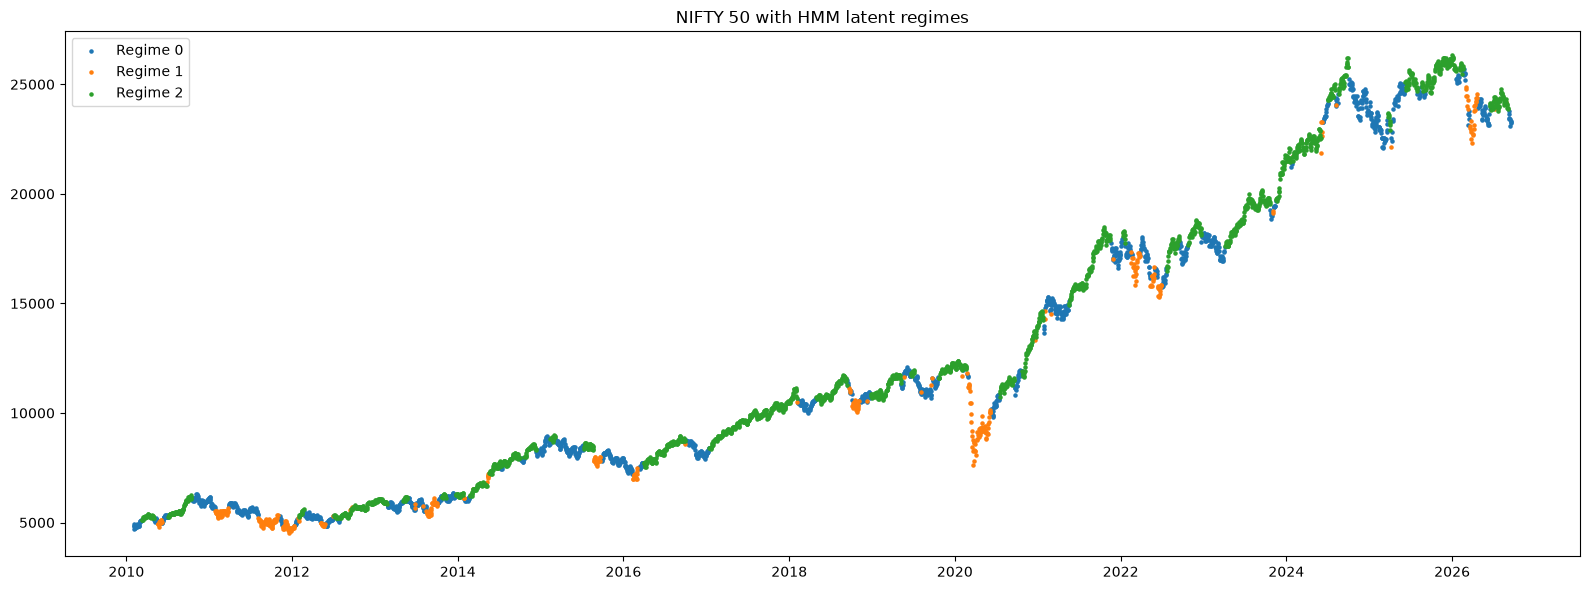

In [3]:
fig, ax = plt.subplots(figsize=(16, 6))
for regime in sorted(state['regime'].dropna().unique()):
    subset = state[state['regime'] == regime]
    ax.scatter(subset.index, subset['nifty_close'], s=5, label=f'Regime {regime}')
ax.set_title('NIFTY 50 with HMM latent regimes')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'hmm_regimes_nifty.png', dpi=180, bbox_inches='tight')
plt.show()

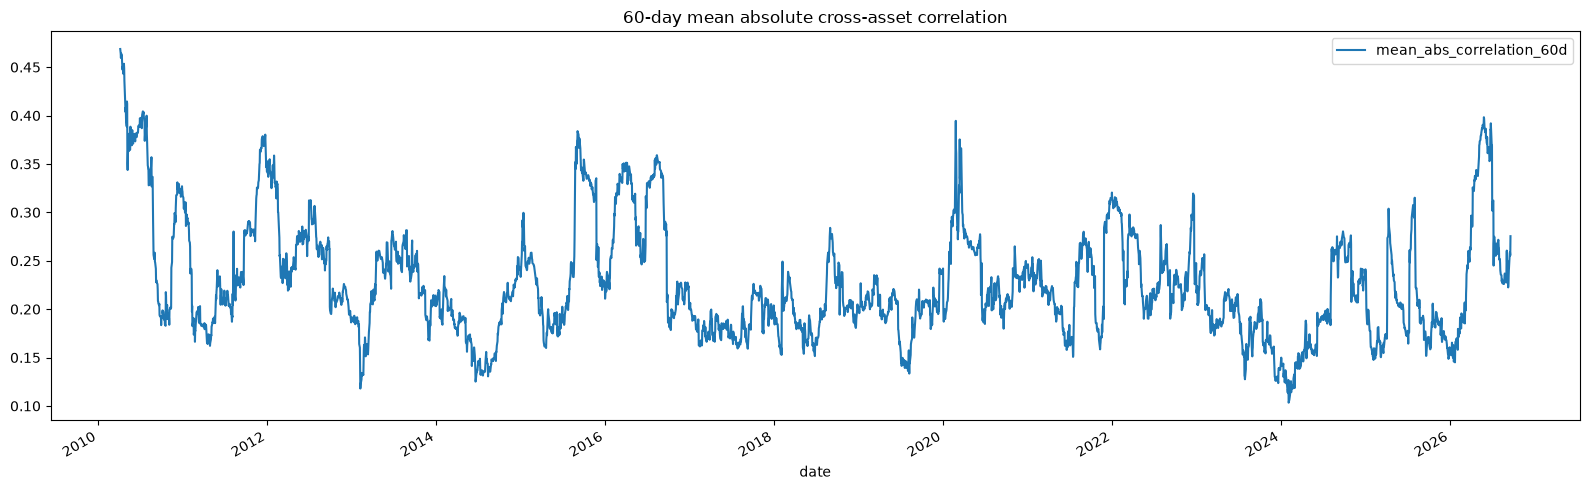

In [4]:
requested_assets = ['nifty_close', 'india_vix', 'usd_inr', 'gold', 'brent', 'sp500', 'us_vix']
asset_columns = [column for column in requested_assets if column in prices.columns]
if len(asset_columns) < 3:
    raise ValueError('Connectedness analysis needs at least three aligned asset series.')
asset_returns = log_returns(prices[asset_columns])
connectedness = rolling_connectedness(asset_returns, window=60)
connectedness.to_csv(PROCESSED_DATA_DIR / 'connectedness_features.csv')
asset_returns.tail(60).corr().to_csv(PROCESSED_DATA_DIR / 'latest_correlation_matrix.csv')
connectedness.plot(figsize=(16, 5), title='60-day mean absolute cross-asset correlation')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rolling_connectedness.png', dpi=180, bbox_inches='tight')
plt.show()

## Next action
Merge regime and connectedness outputs in the supervised model notebook. Use only training-period fitted regime models for genuine walk-forward tests.